In [ ]:
# 1. Install Unsloth & dependencies
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps "xformers<0.0.28" "trl<0.9.0" "peft" "accelerate" "bitsandbytes"

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-wclvy80r/unsloth_b1f5c75cf0ea42999de1078f7a348322
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-wclvy80r/unsloth_b1f5c75cf0ea42999de1078f7a348322
  Resolved https://github.com/unslothai/unsloth.git to commit 0003f889e6b8dd0a8da21cb382f175dab17985ac
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 924.4/924.4 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 17.4 MB/s eta 0:00:00


In [ ]:
from unsloth import FastLanguageModel
import torch
import os
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from google.colab import drive
drive.mount('/content/drive')

# 1. Definisi Path
ROOT_PATH = "/content/drive/MyDrive/SFT"
OUTPUT_PATH = "/content/drive/MyDrive/SFT/Kebutuhan Tim 1/Ujicoba SFT Notebook"
os.makedirs(OUTPUT_PATH, exist_ok=True)
# 2. Setup Model & Tokenizer
MODEL_NAME = "mistralai/Ministral-3-8B-Base-2512"
LEARNING_RATE = 2e-4
BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEP = 16
EPOCH = 1
MAX_SEQ_LENGTH = 2048


print("Setup selesai. Model siap untuk fine-tuning!")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
Mounted at /content/drive
Setup selesai. Model siap untuk fine-tuning!


In [ ]:
# =====================================================================
# CELL BARU: LOGIN CREDENTIALS & CREDENTIALS SETUP
# =====================================================================
import os
import wandb
from huggingface_hub import login

# 1. Isi token kamu di sini
HF_TOKEN = "xxx"
WANDB_KEY = "xxb"

# 2. Eksekusi Login Sistem
os.environ["HF_TOKEN"] = HF_TOKEN
os.environ["HUGGINGFACE_HUB_TOKEN"] = HF_TOKEN
login(token=HF_TOKEN, add_to_git_credential=True)

if WANDB_KEY:
    os.environ["WANDB_API_KEY"] = WANDB_KEY
    wandb.login(key=WANDB_KEY, relogin=True)
    REPORT_TO_VAL = "wandb"
    print("✅ W&B dan Hugging Face Hub berhasil tersambung!")
else:
    REPORT_TO_VAL = "none"
    print("⚠️ API Key W&B kosong, logging W&B dinonaktifkan.")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: halizaapalwan (halizaapalwan-sepuluh-nopember-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ W&B dan Hugging Face Hub berhasil tersambung!


In [ ]:
# 3. Load Model & Tokenizer
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype = None,
    load_in_4bit = True,
)

# 4. Ambil model untuk PEFT (LoRA) agar training lebih efisien
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, # Faktor rank LoRA, bisa diganti 8, 16, 32, atau 64
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 32,
    lora_dropout = 0, #
    bias = "none",    # Unsloth mengoptimalkan bias ke none
    use_gradient_checkpointing = "unsloth", # Menghemat VRAM secara maksimal
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

# 5. Menyuntikkan Chat Template Jinja (Tanpa THINK) ke Tokenizer
no_think_template = """{#- Begin of sequence token. -#}
{{- bos_token }}
{#- Handle system prompt jika ada. -#}
{%- if messages[0]['role'] == 'system' %}
    {{- '[SYSTEM_PROMPT]' + messages[0]['content'] + '[/SYSTEM_PROMPT]' }}
    {%- set loop_messages = messages[1:] %}
{%- else %}
    {%- set loop_messages = messages %}
{%- endif %}
{#- Handle iterasi untuk User dan Assistant -#}
{%- for message in loop_messages %}
    {%- if message['role'] == 'user' %}
        {{- '[INST]' + message['content'] + '[/INST]' }}
    {%- elif message['role'] == 'assistant' %}
        {{- message['content'] + eos_token }}
    {%- endif %}
{%- endfor %}"""

tokenizer.chat_template = no_think_template
tokenizer.pad_token = tokenizer.eos_token

==((====))==  Unsloth 2026.6.1: Fast Ministral3 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json:   0%|          | 0.00/163k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/531 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/131 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/976 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.2k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

## DATA FORMATTING

In [ ]:
# =====================================================================
# CELL 2: DATA FORMATTING & DIRECT TOKENIZATION 
# =====================================================================
import os
from datasets import load_dataset

print("Memuat dataset DFK...")
dataset_path = os.path.join(ROOT_PATH, "datasetSFT_tlr.jsonl")
dataset = load_dataset("json", data_files=dataset_path, split="train")

# 1. Ekstrak tokenizer teks murni secara aman
actual_tokenizer = tokenizer.tokenizer if hasattr(tokenizer, "tokenizer") else tokenizer

# 2. SUNTIKKAN ULANG TEMPLATE JINJA LANGSUNG KE ACTUAL_TOKENIZER
actual_tokenizer.chat_template = no_think_template

# 3. Fungsi untuk mengubah pesan menjadi Token IDs (Text-Only)
def tokenize_and_format_func(examples):
    convos = examples["messages"]

    # Render ke format text prompt Mistral tanpa THINK menggunakan actual_tokenizer
    templated_texts = [
        actual_tokenizer.apply_chat_template(convo, tokenize=False, add_generation_prompt=False)
        for convo in convos
    ]

    # Tokenisasi langsung teks tersebut menjadi angka (IDs)
    tokenized = actual_tokenizer(
        templated_texts,
        truncation=False,            
        add_special_tokens=False     # Karena template Jinja kita sudah membuat BOS/EOS sendiri
    )

    # Hitung panjang token untuk keperluan filtering cepat di Cell 3
    token_lengths = [len(ids) for ids in tokenized["input_ids"]]

    return {
        "input_ids": tokenized["input_ids"],
        "attention_mask": tokenized["attention_mask"],
        "token_len": token_lengths,
        "raw_text": templated_texts  
    }

print("Memproses format prompt dan melakukan tokenisasi langsung...")
dataset_processed = dataset.map(tokenize_and_format_func, batched=True)

dataset_processed = dataset_processed.remove_columns(["messages"])

print("\n✅ Proses Tokenisasi Selesai Tanpa Error!")
print(f"Kolom yang tersedia sekarang: {dataset_processed.column_names}")

Memuat dataset DFK...


Generating train split: 0 examples [00:00, ? examples/s]

Memproses format prompt dan melakukan tokenisasi langsung...


Map:   0%|          | 0/26342 [00:00<?, ? examples/s]


✅ Proses Tokenisasi Selesai Tanpa Error!
Kolom yang tersedia sekarang: ['input_ids', 'attention_mask', 'token_len', 'raw_text']


## DISTRIBUSI & FILTER DATA

In [ ]:
# =====================================================================
# CELL 2: LOAD PRE-SPLIT DATASET & DIRECT TOKENIZATION
# =====================================================================
import os
from datasets import load_dataset

print("Memuat dataset DFK yang sudah terbagi (Pre-Split)...")

data_files = {
    "train": os.path.join(ROOT_PATH, "train.jsonl"),
    "validation": os.path.join(ROOT_PATH, "val.jsonl"),
    "test": os.path.join(ROOT_PATH, "test.jsonl")
}

# Muat ketiga subset sekaligus ke dalam satu objek DatasetDict
dataset_split = load_dataset("json", data_files=data_files)

print(f"✅ Berhasil memuat dataset split!")
print(f"Struktur data saat ini:\n{dataset_split}")

# 1. Ekstrak tokenizer teks murni secara aman
actual_tokenizer = tokenizer.tokenizer if hasattr(tokenizer, "tokenizer") else tokenizer

# 2. Pastikan template Jinja terkunci pada tokenizer
actual_tokenizer.chat_template = no_think_template

# 3. Fungsi tokenisasi khusus untuk struktur DatasetDict
def tokenize_split_func(examples):
    # Karena data hasil ekspor CELL 4 formatnya langsung string di kolom "text"
    templated_texts = examples["text"]

    # Tokenisasi langsung teks tersebut menjadi angka (IDs)
    tokenized = actual_tokenizer(
        templated_texts,
        truncation=False,          
        add_special_tokens=False   
    )

    return {
        "input_ids": tokenized["input_ids"],
        "attention_mask": tokenized["attention_mask"]
    }

print("\nMemproses tokenisasi langsung pada subset Train, Val, dan Test...")
# Melakukan map ke seluruh subset secara otomatis (train, validation, test)
dataset_processed = dataset_split.map(tokenize_split_func, batched=True)

# Definisikan variabel subset global agar sel evaluasi/training di bawah tinggal panggil
train_ds = dataset_processed["train"]
val_ds = dataset_processed["validation"]
test_ds = dataset_processed["test"]

print("\n✅ Proses Tokenisasi Paket Data Bersih Selesai Tanpa Error!")
print(f"Kolom final pada train_ds: {train_ds.column_names} (Total: {len(train_ds)} baris)")
print(f"Kolom final pada test_ds : {test_ds.column_names} (Total: {len(test_ds)} baris)")

Memuat dataset DFK yang sudah terbagi (Pre-Split)...
✅ Berhasil memuat dataset split!
Struktur data saat ini:
DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 20790
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 2599
    })
    test: Dataset({
        features: ['text'],
        num_rows: 2599
    })
})

Memproses tokenisasi langsung pada subset Train, Val, dan Test...

✅ Proses Tokenisasi Paket Data Bersih Selesai Tanpa Error!
Kolom final pada train_ds: ['text', 'input_ids', 'attention_mask'] (Total: 20790 baris)
Kolom final pada test_ds : ['text', 'input_ids', 'attention_mask'] (Total: 2599 baris)


Membaca paket data bersih untuk visualisasi...
Menghitung parameter grafik...


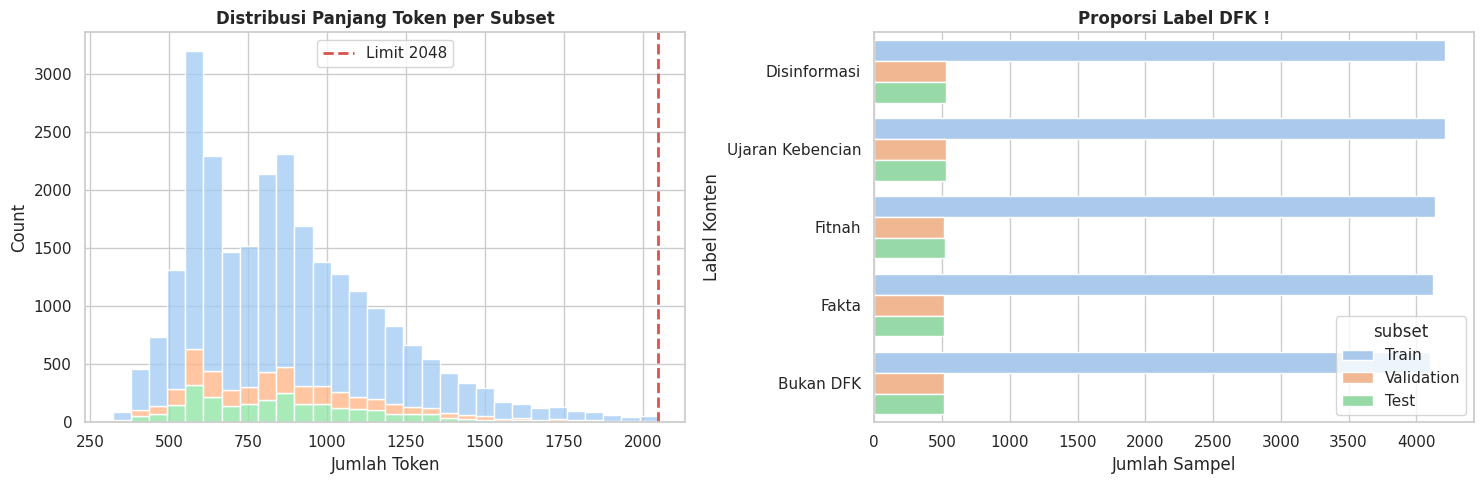


 Total Keseluruhan Data Masuk: 25988 baris

[Subset: Train] (Total: 20790 baris)
                  Jumlah Data Persentase
label                                   
Disinformasi             4215     20.27%
Ujaran Kebencian         4213     20.26%
Fitnah                   4137     19.90%
Fakta                    4125     19.84%
Bukan DFK                4100     19.72%
---------------------------------------------

[Subset: Validation] (Total: 2599 baris)
                  Jumlah Data Persentase
label                                   
Disinformasi              527     20.28%
Ujaran Kebencian          527     20.28%
Fitnah                    517     19.89%
Fakta                     515     19.82%
Bukan DFK                 513     19.74%
---------------------------------------------

[Subset: Test] (Total: 2599 baris)
                  Jumlah Data Persentase
label                                   
Disinformasi              527     20.28%
Ujaran Kebencian          526     20.24%
Fitnah    

In [ ]:
# =====================================================================
# CELL 3: VISUALISASI DISTRIBUSI PAKET DATA BERSIH (AFTER FILTER)
# =====================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
DATASET_PATH = "/content/drive/MyDrive/SFT/NEW"
print("Membaca paket data bersih untuk visualisasi...")
# Memuat file jsonl menjadi DataFrame pandas secara instan
df_train = pd.read_json(os.path.join(ROOT_PATH, "train.jsonl"), lines=True)
df_val = pd.read_json(os.path.join(ROOT_PATH, "val.jsonl"), lines=True)
df_test = pd.read_json(os.path.join(ROOT_PATH, "test.jsonl"), lines=True)

# Tambahkan penanda subset
df_train["subset"] = "Train"
df_val["subset"] = "Validation"
df_test["subset"] = "Test"

# Gabungkan untuk melihat total distribusi
df_all = pd.concat([df_train, df_val, df_test]).reset_index(drop=True)

# 1. Hitung ulang panjang token & ekstrak label untuk keperluan grafik
print("Menghitung parameter grafik...")
actual_tokenizer = tokenizer.tokenizer if hasattr(tokenizer, "tokenizer") else tokenizer

df_all["token_len"] = [len(actual_tokenizer.encode(t, add_special_tokens=False)) for t in df_all["text"]]

def extract_label_clean(text):
    parts = text.split("[/INST]")
    if len(parts) < 2: return "Unknown"
    assistant_response = parts[1]
    match = re.search(r"Label:\s*\*\*(.*?)\*\*", assistant_response, re.IGNORECASE)
    if match:
        return match.group(1).replace(".", "").strip()
    return "Unknown"

df_all["label"] = [extract_label_clean(t) for t in df_all["text"]]

# =====================================================================
# 2. PROSES PLOTTING GRAFIK 
# =====================================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Distribusi Panjang Token
sns.histplot(data=df_all, x="token_len", hue="subset", multiple="stack", ax=axes[0], palette="pastel", bins=30)
axes[0].set_title("Distribusi Panjang Token per Subset", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Jumlah Token")
axes[0].axvline(2048, color='#d9534f', linestyle='--', linewidth=2, label='Limit 2048')
axes[0].legend()

# Plot 2: Distribusi Label per Kelas
df_labels = df_all[df_all["label"] != "Unknown"]
sns.countplot(y=df_labels["label"], ax=axes[1], palette="pastel",
              order=df_labels["label"].value_counts().index,
              hue=df_labels["subset"])
axes[1].set_title("Proporsi Label DFK !", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Jumlah Sampel")
axes[1].set_ylabel("Label Konten")

plt.tight_layout()
plt.show()

# =====================================================================
# 3. PRINT DETAIL DISTRIBUSI LABEL DAN PERSENTASE PER SUBSET
# =====================================================================
print("\n" + "="*60)
print(f" Total Keseluruhan Data Masuk: {len(df_all)} baris")
print("="*60)

# Looping untuk membedah tiap subset secara detail
for target_subset in ["Train", "Validation", "Test"]:
    df_subset = df_all[df_all["subset"] == target_subset]

    print(f"\n[Subset: {target_subset}] (Total: {len(df_subset)} baris)")

    # Hitung count dan percentage secara bersamaan
    counts = df_subset["label"].value_counts()
    percentages = df_subset["label"].value_counts(normalize=True).map('{:.2%}'.format)

    # Gabungkan ke dalam dataframe summary
    summary_df = pd.DataFrame({
        'Jumlah Data': counts,
        'Persentase': percentages
    })
    print(summary_df)
    print("-" * 45)

In [ ]:
# =====================================================================
# CELL 6: SIMULASI & VERIFIKASI MASKING LOSS (VERSI RINGAN & AMAN)
# =====================================================================
from trl import DataCollatorForCompletionOnlyLM

# 1. Ekstrak tokenizer murni secara aman
actual_tokenizer = tokenizer.tokenizer if hasattr(tokenizer, "tokenizer") else tokenizer

# 2. Inisialisasi Data Collator dengan tokenizer murni
collator = DataCollatorForCompletionOnlyLM(
    response_template="[/INST]",
    tokenizer=actual_tokenizer
)

# 3. Ambil 1 sampel teks mentah dari train_ds hasil split Cell 4
text_sample = train_ds[0]["text"]

# Lakukan tokenisasi mandiri khusus untuk simulasi visual ini
tokenized_sample = actual_tokenizer(
    text_sample,
    truncation=True,
    max_length=MAX_SEQ_LENGTH,
    add_special_tokens=False
)

# Amankan struktur data menjadi dictionary murni dalam list
sample_data = [dict(tokenized_sample)]

# 4. Jalankan collator secara manual
print("Sedang memproses masking data...")
collated_sample = collator(sample_data)

input_ids = collated_sample["input_ids"][0].tolist()
labels = collated_sample["labels"][0].tolist()

# 5. TAMPILAN ANALISIS TERBATAS (ANTI-STUCK)
print("\n=== VERIFIKASI AREA TRANSISI MASKING ===")
print(f"{'INDEX':<6} | {'TOKEN ID':<9} | {'LABEL ID':<9} | {'STATUS':<12} | {'DECODED TEXT'}")
print("-" * 75)

# Cari di mana letak transisi dari MASKED (-100) ke LEARN (bukan -100)
transition_idx = 0
for i, label_id in enumerate(labels):
    if label_id != -100:
        transition_idx = i
        break

# Tentukan jendela index yang ingin dicetak agar notebook tidak freeze
# Kita cetak 5 token awal, dan 25 token sebelum/sesudah transisi
for idx, (token_id, label_id) in enumerate(zip(input_ids, labels)):
    token_text = actual_tokenizer.decode([token_id])

    if label_id == -100:
        status = "\033[91mMASKED\033[0m"
        label_str = "-100"
        text_color = f"\033[90m{repr(token_text)}\033[0m"
    else:
        status = "\033[1;92mLEARN\033[0m"
        label_str = str(label_id)
        text_color = f"\033[1;92m{repr(token_text)}\033[0m"

    # Kondisi cetak: Hanya token awal dan token di sekitar area transisi [/INST]
    if idx < 5 or (transition_idx - 20 <= idx <= transition_idx + 25) or idx >= len(input_ids) - 3:
        print(f"{idx:<6} | {token_id:<9} | {label_str:<9} | {status:<21} | {text_color}")
    elif idx == 5:
        print(f"... [ {transition_idx - 25} Token Prompt Dimasking Disembunyikan Agar Tidak Lag ] ...")
    elif idx == transition_idx + 26:
        print(f"... [ Sisa Token Jawaban Model Disembunyikan ] ...")

print("-" * 75)
print(f"✅ Total Token Semuanya : {len(input_ids)}")
print(f"✅ Total Token yang Di-mask (-100) : {labels.count(-100)}")
print(f"✅ Total Token Target Jawaban (Loss > 0) : {len(labels) - labels.count(-100)}")

Sedang memproses masking data...

=== VERIFIKASI AREA TRANSISI MASKING ===
INDEX  | TOKEN ID  | LABEL ID  | STATUS       | DECODED TEXT
---------------------------------------------------------------------------
0      | 1         | -100      | MASKED       | '<s>'
1      | 17        | -100      | MASKED       | '[SYSTEM_PROMPT]'
2      | 4998      | -100      | MASKED       | 'And'
3      | 1097      | -100      | MASKED       | 'a'
4      | 16669     | -100      | MASKED       | ' adalah'
... [ 337 Token Prompt Dimasking Disembunyikan Agar Tidak Lag ] ...
342    | 44801     | -100      | MASKED       | ' berg'
343    | 6028      | -100      | MASKED       | 'una'
344    | 1044      | -100      | MASKED       | ','
345    | 80535     | -100      | MASKED       | ' objek'
346    | 1044      | -100      | MASKED       | ','
347    | 5441      | -100      | MASKED       | ' mer'
348    | 1474      | -100      | MASKED       | 'end'
349    | 40596     | -100      | MASKED       | 'ahkan'


## **Training**

In [ ]:
# =====================================================================
# CELL 6: DATA COLLATOR DENGAN JINJA MINISTRAL TEMPLATE (PERBAIKAN)
# =====================================================================
from trl import DataCollatorForCompletionOnlyLM
import torch

# 1. Ekstrak tokenizer teks murni secara aman dari Unsloth wrapper
actual_tokenizer = tokenizer.tokenizer if hasattr(tokenizer, "tokenizer") else tokenizer

# 2. KUNCI TEMPLATE MINISTRAL ASLI KAMU (<s> [INST] ... [/INST])
actual_tokenizer.chat_template = no_think_template

# 3. Inisialisasi collator resmi TRL untuk memotong loss tepat di target [/INST]
collator = DataCollatorForCompletionOnlyLM(
    response_template="[/INST]",
    tokenizer=actual_tokenizer
)

# 4. Fungsi Pembungkus Batch untuk HF Trainer Standar
def hf_on_the_fly_collator(features):
    # Ambil teks mentah dari data train_ds (sisa split sukses Cell 4 kamu)
    texts = [f["text"] for f in features]

    # Jalankan tokenisasi murni teks via actual_tokenizer Ministral
    tokenized = actual_tokenizer(
        texts,
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
        padding=True,
        return_tensors="pt",       # Kembalikan bentuk PyTorch Tensor asli
        add_special_tokens=False   # False karena template Jinja kamu sudah bawa token <s> sendiri
    )

    # Kembalikan bentuk list dict mentah sesuai kontrak DataCollatorForCompletionOnlyLM
    list_features = [
        {
            "input_ids": tokenized["input_ids"][i].tolist(),
            "attention_mask": tokenized["attention_mask"][i].tolist()
        }
        for i in range(len(texts))
    ]

    # Biarkan TRL membuat kolom 'labels' dan menutup loss bagian [INST] dengan nilai -100
    batch = collator(list_features)

    # Pastikan seluruh isi batch dikunci ke PyTorch LongTensor agar aman
    safe_batch = {}
    for key, value in batch.items():
        safe_batch[key] = value.to(dtype=torch.long) if isinstance(value, torch.Tensor) else torch.tensor(value, dtype=torch.long)

    return safe_batch

print("Collator On-The-Fly dengan Template Ministral Asli SIAP!")

Collator On-The-Fly dengan Template Ministral Asli SIAP!


In [ ]:
batch = hf_on_the_fly_collator([train_ds[0], train_ds[1]])

for k, v in batch.items():
    print(k, v.shape, v.dtype)

input_ids torch.Size([2, 1657]) torch.int64
attention_mask torch.Size([2, 1657]) torch.int64
labels torch.Size([2, 1657]) torch.int64


In [ ]:
model.eval()

batch = hf_on_the_fly_collator([train_ds[0], train_ds[1]])

batch = {k: v.to(model.device) for k, v in batch.items()}

with torch.no_grad():
    outputs = model(**batch)

print(outputs.loss.item())

/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:239: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:186: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:239: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:186: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bits

1.5848180055618286


In [ ]:
labels = batch["labels"][0]

masked = (labels == -100).sum().item()
learn  = (labels != -100).sum().item()

print(masked, learn)
print("ratio:", learn / len(labels))

1480 177
ratio: 0.10681955340977671


In [ ]:
import numpy as np

learn_counts = []

for i in range(100):
    batch = hf_on_the_fly_collator([train_ds[i]])
    labels = batch["labels"][0]

    learn = (labels != -100).sum().item()
    learn_counts.append(learn)

print("mean :", np.mean(learn_counts))
print("min  :", np.min(learn_counts))
print("max  :", np.max(learn_counts))
print("median:", np.median(learn_counts))

mean : 218.83
min  : 122
max  : 367
median: 221.5


In [ ]:
# =====================================================================
# CELL 7: TRAINING CONFIGURATION & FINE-TUNING (W&B ENABLED)
# =====================================================================
from transformers import Trainer, TrainingArguments
import transformers.trainer as _hf_trainer
import torch
import torch.nn as nn


# 2. Variabel Batching Teroptimasi (Speed Mode)
NEW_BATCH_SIZE = 2
NEW_GRAD_ACC = 16

# 3. Konfigurasi Parameter TrainingArguments (W&B Active)
training_args = TrainingArguments(
    per_device_train_batch_size = NEW_BATCH_SIZE,
    gradient_accumulation_steps = NEW_GRAD_ACC,
    warmup_steps = 20,
    num_train_epochs = EPOCH,
    learning_rate = LEARNING_RATE,
    fp16 = not torch.cuda.is_bf16_supported(),
    bf16 = torch.cuda.is_bf16_supported(),
    logging_steps = 1,
    eval_strategy = "steps",
    eval_steps = 200,
    save_steps = 200,
    optim = "adamw_8bit",
    weight_decay = 0.01,
    lr_scheduler_type = "linear",
    seed = 3407,
    # output_dir = OUTPUT_PATH,
    remove_unused_columns = False,
    dataloader_num_workers = 2,
    dataloader_pin_memory = True,

    save_total_limit = 3,
    output_dir = os.path.join(OUTPUT_PATH, "dfk_local_checkpoints"),
    # Kunci integrasi W&B:
    report_to = REPORT_TO_VAL,
    run_name = "sft-ministral-base2-dfk"
)

# 4. Inisialisasi Trainer Standar
trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = train_ds,
    eval_dataset = val_ds,
    data_collator = hf_on_the_fly_collator,
)

print("=" * 50)
print("MEMULAI PROSES SUPERVISED FINE-TUNING + LOGGING W&B...")
print("=" * 50)

trainer_stats = trainer.train()

print("\n" + "=" * 50)
print("TRAINING BERHASIL SELESAI!")
print("=" * 50)

MEMULAI PROSES SUPERVISED FINE-TUNING + LOGGING W&B...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 20,790 | Num Epochs = 1 | Total steps = 650
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 16 x 1) = 32
 "-____-"     Trainable parameters = 53,608,448 of 8,971,634,688 (0.60% trained)


wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai


Unsloth: Will smartly offload gradients to save VRAM!


/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:239: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:186: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:239: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:186: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bits

Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
200,0.404838,0.403779
400,0.376199,0.380774
600,0.393919,0.367714
650,0.376871,0.366221



TRAINING BERHASIL SELESAI!


## **SAVE AND MERGE**

In [ ]:
# =====================================================================
# CELL 8: SAVE & PUSH LORA ADAPTERS TO HUGGINGFACE
# =====================================================================
import os

HF_LORA_REPO_ID = "hnuka/Ministral-8B-base-DFK-LoRA-Base"
# LOCAL_OUTPUT_PATH = "./dfk_local_lora_adapter"
LOCAL_OUTPUT_PATH = f"{OUTPUT_PATH}/BEST_base_lora_adapter"


print(f"Menyimpan LoRA adapter secara lokal ke: {LOCAL_OUTPUT_PATH}...")
model.save_pretrained(LOCAL_OUTPUT_PATH)
actual_tokenizer.save_pretrained(LOCAL_OUTPUT_PATH)

# print(f"Menyimpan LoRA adapter secara lokal ke: {OUTPUT_PATH}...")
# model.save_pretrained(OUTPUT_PATH)
# actual_tokenizer.save_pretrained(OUTPUT_PATH)

print(f"Mengunggah LoRA Adapter + Chat Template Jinja ke HF Hub: {HF_LORA_REPO_ID}...")
model.push_to_hub(HF_LORA_REPO_ID, private=False)
actual_tokenizer.push_to_hub(HF_LORA_REPO_ID, private=False)

print("Sukses! LoRA Adapter dan Chat Template Jinja sudah aman di HF Hub.")

Menyimpan LoRA adapter secara lokal ke: /content/drive/MyDrive/SFT/Kebutuhan Tim 1/Ujicoba SFT Notebook/BEST_base_lora_adapter...


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/SFT/Kebutuhan Tim 1/Ujicoba SFT Notebook/BEST_base_lora_adapter/tokenizer_config.json.


Mengunggah LoRA Adapter + Chat Template Jinja ke HF Hub: hnuka/Ministral-8B-base-DFK-LoRA-Base...


README.md:   0%|          | 0.00/591 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

...

Unsloth: Restored added_tokens_decoder metadata in /tmp/tmpzpnr1v21/tokenizer_config.json.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpzpnr1v21/tokenizer.json: 100%|#########9| 17.0MB / 17.1MB            

Sukses! LoRA Adapter dan Chat Template Jinja sudah aman di HF Hub.


In [ ]:
# =====================================================================
# CELL 10: MERGE & PUSH VIA UNSLOTH NATIVE METHOD (FIXED)
# =====================================================================

import os

# DEFINE REPOSITORI BARU AGAR BERSIH DAN TIDAK TERCAMPUR FILE LAMA
HF_MERGED_SHARDED_REPO = "hnuka/BEST-Ministral-8B-DFK-Base-Sharded"
HF_MERGED_FULL_REPO = "hnuka/BEST-Ministral-8B-DFK-Base"

# Pastikan token Hugging Face Anda sudah terpasang/login
# via notebook_login() atau os.environ["HF_TOKEN"]

print("=" * 60)
print("PUSHING SHARDED MODEL DIRECTLY TO HUGGINGFACE HUB...")
print("=" * 60)

# 1. Gunakan fungsi native Unsloth untuk push versi Sharded (16bit)
# Unsloth akan otomatis melakukan merge_and_unload secara aman di latar belakang
model.push_to_hub_merged(
    HF_MERGED_SHARDED_REPO,
    tokenizer,
    save_method="merged_16bit",  # Menggabungkan LoRA ke 16-bit float
    max_shard_size="5GB"         # Dipecah per 5GB
)

print("=" * 60)
print("PUSHING FULL MODEL DIRECTLY TO HUGGINGFACE HUB...")
print("=" * 60)

# 2. Gunakan fungsi native Unsloth untuk push versi Utuh tanpa potongan
model.push_to_hub_merged(
    HF_MERGED_FULL_REPO,
    tokenizer,
    save_method="merged_16bit",
    max_shard_size="50GB"        # Batas besar agar menjadi single file
)

print("=" * 60)
print("SEMUA PROSES SELESAI DENGAN AMAN!")
print("=" * 60)

print(f"Versi Sharded Baru: https://huggingface.co/{HF_MERGED_SHARDED_REPO}")
print(f"Versi Full Baru:    https://huggingface.co/{HF_MERGED_FULL_REPO}")

PUSHING SHARDED MODEL DIRECTLY TO HUGGINGFACE HUB...


config.json:   0%|          | 0.00/1.68k [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in hnuka/BEST-Ministral-8B-DFK-Base-Sharded/tokenizer_config.json.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...0004-of-00004.safetensors:   7%|7         |  208MB / 2.94GB            


Unsloth: Merging weights into 16bit: 100%|██████████| 4/4 [02:39<00:00, 39.99s/it]


Unsloth: Merge process complete. Saved to `/content/hnuka/BEST-Ministral-8B-DFK-Base`
SEMUA PROSES SELESAI DENGAN AMAN!
Versi Sharded Baru: https://huggingface.co/hnuka/BEST-Ministral-8B-DFK-Base-Sharded
Versi Full Baru:    https://huggingface.co/hnuka/BEST-Ministral-8B-DFK-Base


In [ ]:
# from huggingface_hub import HfApi

# LOCAL_DIR = "./model_full_unsloth"
# # Sesuai dengan tujuan awal kamu (tanpa embel-embel -Full di belakang)
# HF_FULL_REPO = "hnuka/BEST-Ministral-8B-DFK-Base-V1"

# api = HfApi()

# print("1. Memastikan/Membuat repositori di Hugging Face Hub...")
# try:
#     # Membuat repo baru jika belum ada secara otomatis
#     api.create_repo(repo_id=HF_FULL_REPO, repo_type="model", exist_ok=True)
#     print(f"Repo {HF_FULL_REPO} siap!")
# except Exception as e:
#     print(f"Catatan saat cek/buat repo: {e}")

# print("\n2. Mengunggah folder lokal (1 file utuh) ke Hugging Face Hub...")
# # Proses ini akan mengunggah file model.safetensors utuh (~16GB)
# api.upload_folder(
#     folder_path=LOCAL_DIR,
#     repo_id=HF_FULL_REPO,
#     repo_type="model"
# )

# print("\n" + "=" * 60)
# print("PROSES FINISHED SKSES DAN AMAN!")
# print("=" * 60)
# print(f"Silakan cek file utuh Anda di: https://huggingface.co/{HF_FULL_REPO}")

1. Memastikan/Membuat repositori di Hugging Face Hub...
Repo hnuka/BEST-Ministral-8B-DFK-Base-V1 siap!

2. Mengunggah folder lokal (1 file utuh) ke Hugging Face Hub...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...0002-of-00004.safetensors:   4%|3         |  176MB / 5.00GB            

  ...0004-of-00004.safetensors:   6%|5         |  168MB / 2.94GB            

  ...0003-of-00004.safetensors:   4%|3         |  176MB / 4.92GB            

  ...ll_unsloth/tokenizer.json: 100%|##########| 17.1MB / 17.1MB            

  ...0001-of-00004.safetensors:   4%|3         |  176MB / 4.98GB            


PROSES FINISHED SKSES DAN AMAN!
Silakan cek file utuh Anda di: https://huggingface.co/hnuka/BEST-Ministral-8B-DFK-Base-V1


In [ ]:
# # =====================================================================
# # CELL 9: ULTIMATE FIX - MERGE LORA & PUSH FULL MODEL VIA ORIGINAL PEFT
# # =====================================================================
# from transformers import AutoModelForCausalLM, AutoTokenizer
# from peft import PeftModel
# from huggingface_hub import HfApi
# import torch
# import gc
# import os
# import shutil

# # 1. TENTUKAN PATH REPO DAN FOLDER
# LOCAL_LORA_PATH = "./dfk_local_lora_adapter"
# HF_FULL_REPO_ID = "hnuka/Ministral-8B-DFK-Full-Merged"
# TEMP_MERGED_DIR = "./temp_merged_model_16bit"

# # Pembersihan VRAM awal
# gc.collect()
# torch.cuda.empty_cache()

# print("1. Memuat Base Model asli Ministral dalam format 16-bit (bfloat16)...")
# # Kita panggil langsung base model Ministral asli menggunakan standard Hugging Face
# base_model = AutoModelForCausalLM.from_pretrained(
#     "mistralai/Ministral-8B-Instruct-2410", # Base model asli Ministral kamu
#     torch_dtype = torch.bfloat16,
#     device_map = "auto",
#     trust_remote_code = True
# )

# print("2. Memuat Tokenizer dan mengunci Chat Template...")
# tokenizer_fresh = AutoTokenizer.from_pretrained("mistralai/Ministral-8B-Instruct-2410", trust_remote_code=True)
# tokenizer_fresh.chat_template = no_think_template

# print("3. Menyuntikkan LoRA Adapter lokal ke dalam Base Model...")
# # Menggunakan PeftModel bawaan Hugging Face untuk menggabungkan adapter lokal secara presisi
# model_peft = PeftModel.from_pretrained(base_model, LOCAL_LORA_PATH)

# print("4. Mengeksekusi proses penggabungan bobot (Merge and Unload)...")
# # Mengunci penjumlahan bobot W_base + Delta_W menjadi satu kesatuan 16-bit
# model_merged = model_peft.merge_and_unload()
# print("Penggabungan bobot selesai sukses!")

# print("5. Menyimpan Full Model secara lokal di SSD kontainer...")
# os.makedirs(TEMP_MERGED_DIR, exist_ok=True)
# model_merged.save_pretrained(TEMP_MERGED_DIR, safe_serialization=True, max_shard_size="5GB")
# tokenizer_fresh.save_pretrained(TEMP_MERGED_DIR)
# print("Seluruh berkas model berhasil di-shard per 5GB di folder lokal.")

# # Hapus model dari RAM/VRAM agar ruang kembali 100% kosong sebelum upload
# del base_model, model_peft, model_merged
# gc.collect()
# torch.cuda.empty_cache()

# print("6. Mengunggah folder secara aman via Hugging Face API murni...")
# api = HfApi()
# api.upload_folder(
#     folder_path = TEMP_MERGED_DIR,
#     repo_id = HF_FULL_REPO_ID,
#     repo_type = "model"
# )
# print("🎉 SUKSES TOTAL! Seluruh file model.safetensors sudah masuk utuh ke repositori HF kamu!")

# print("7. Membersihkan sisa penyimpanan lokal...")
# if os.path.exists(TEMP_MERGED_DIR):
#     shutil.rmtree(TEMP_MERGED_DIR)
# print("Penyimpanan lokal bersih kembali.")

1. Memuat Base Model asli Ministral dalam format 16-bit (bfloat16)...


config.json:   0%|          | 0.00/1.41k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/26.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/327 [00:00<?, ?it/s]

...

  ...0003-of-00004.safetensors:   2%|1         | 87.9MB / 4.97GB            

  ...0004-of-00004.safetensors:   1%|1         | 15.9MB / 1.20GB            

  ...0001-of-00004.safetensors:   3%|2         |  128MB / 4.95GB            

  ...0002-of-00004.safetensors:   1%|          | 48.0MB / 4.92GB            

🎉 SUKSES TOTAL! Seluruh file model.safetensors sudah masuk utuh ke repositori HF kamu!
7. Membersihkan sisa penyimpanan lokal...
Penyimpanan lokal bersih kembali.
